# Лабораторная работа №5
## Графы
## Ревенко Данила, ФИТ-231
### № 1
В примере алгоритма поиска в ширину из лекции
(https://cloud.mail.ru/public/9yCy/LitbGAfEg) структура данных граф представлена
словарем. Переделайте этот пример, заменив словарь на реализацию класса Graph из
лекционных материалов.


In [3]:
from collections import deque

class Vertex:
    def __init__(self, key):
        self.id = key
        self.connectedTo = {}

    def addNeighbor(self, nbr, weight=0):
        self.connectedTo[nbr] = weight

    def __str__(self):
        return str(self.id) + ' connectedTo: ' + str([x.id for x in self.connectedTo])

    def getConnections(self):
        return self.connectedTo.keys()

    def getId(self):
        return self.id

    def getWeight(self, nbr):
        return self.connectedTo[nbr]


class Graph:
    def __init__(self):
        self.vertList = {}
        self.numVertices = 0

    def addVertex(self, key):
        self.numVertices = self.numVertices + 1
        newVertex = Vertex(key)
        self.vertList[key] = newVertex
        return newVertex

    def getVertex(self, n):
        if n in self.vertList:
            return self.vertList[n]
        else:
            return None

    def __contains__(self, n):
        return n in self.vertList

    def addEdge(self, f, t, cost=0):
        if f not in self.vertList:
            self.addVertex(f)
        if t not in self.vertList:
            self.addVertex(t)
        self.vertList[f].addNeighbor(self.vertList[t], cost)

    def getVertices(self):
        return self.vertList.keys()

    def __iter__(self):
        return iter(self.vertList.values())

def person_is_seller(name):
    return name[0] == 'a'

g = Graph()
for name in ["you", "alice", "bob", "claire", "anuj", "peggy", "thom", "jonny"]:
    g.addVertex(name)
g.addEdge("you", "alice")
g.addEdge("you", "bob")
g.addEdge("you", "claire")
g.addEdge("bob", "anuj")
g.addEdge("bob", "peggy")
g.addEdge("alice", "peggy")
g.addEdge("claire", "thom")
g.addEdge("claire", "jonny")

def search(start_name):
    start_vertex = g.getVertex(start_name)
    search_queue = deque()
    search_queue.extend(start_vertex.getConnections())
    searched = set()
    while search_queue:
        person_vertex = search_queue.popleft()
        name = person_vertex.getId()
        if name not in searched:
            if person_is_seller(name):
                print(f"{name} is a mango seller!")
                return True
            else:
                search_queue.extend(person_vertex.getConnections())
                searched.add(name)
    return False

search("you")

alice is a mango seller!


True

### №2
Реализуйте программу, которая по заданному в виде списка смежности графу строит
обращённый граф (тоже в виде списка смежности). Обращённый граф получается
изменением направления всех рёбер исходного графа. Используйте класс Graph из
лекционных материалов.


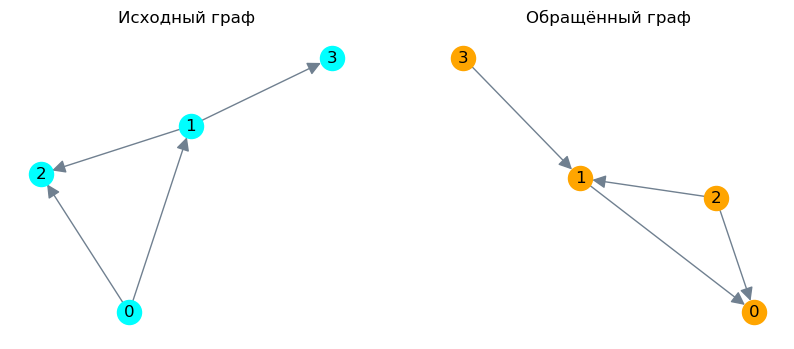

In [7]:
import networkx as nx
import matplotlib.pyplot as plt


# Функция для получения обратного графа на основе вашей реализации
def get_reverse_graph(graph):
    reverse_g = Graph()
    for v in graph.getVertices():
        reverse_g.addVertex(v)
    for vertex in graph:
        for neighbor in vertex.getConnections():
            reverse_g.addEdge(neighbor.getId(), vertex.getId())
    return reverse_g

# Пример исходного графа
g = Graph()
for v in [0, 1, 2, 3]:
    g.addVertex(v)
g.addEdge(0, 1)
g.addEdge(0, 2)
g.addEdge(1, 2)
g.addEdge(1, 3)

# Получим обращённый граф
reverse_g = get_reverse_graph(g)

def graph_to_networkx(graph):
    G = nx.DiGraph()  # направленный граф
    for v in graph.getVertices():
        G.add_node(v)
    for vertex in graph:
        for neighbor in vertex.getConnections():
            G.add_edge(vertex.getId(), neighbor.getId())
    return G

G_orig = graph_to_networkx(g)
G_rev = graph_to_networkx(reverse_g)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
nx.draw(G_orig, with_labels=True, node_color='cyan', edge_color='slategray', arrowsize=20)
plt.title("Исходный граф")

plt.subplot(1,2,2)
nx.draw(G_rev, with_labels=True, node_color='orange', edge_color='slategray', arrowsize=20)
plt.title("Обращённый граф")

plt.show()

### №3
Пусть у вас имеется следующий рецепт блинов: одно яйцо, одна чашка блинной смеси, одна
столовая ложка растительного масла и 3/4 чашки молока. Чтобы нажарить блинов, вам
нужно разогреть сковородку, смешать вместе все ингредиенты и выливать смесь по ложке
на горячую сковороду. Когда блин начинает пузыриться, переверните его и дождитесь, пока
нижняя сторона не станет золотистой. Перед тем, как приступить к поеданию блинов,
полейте их сиропом. Весь процесс показан в виде графа.
Напишите программу, которая при помощи поиска в глубину (Depth-first search, DFS)
проведет топологическую сортировку представленного графа и выдаст вариант корректной
последовательности шагов. Например:
Используйте класс Graph из лекционных материалов.

Топологически отсортированные шаги:
1. heat griddle
2. 3/4 cup milk
3. 1 egg
4. 1 Tbl Oil
5. 1 cup mix
6. heat syrup
7. pour 1/4 cup
8. turn when bubbly
9. eat


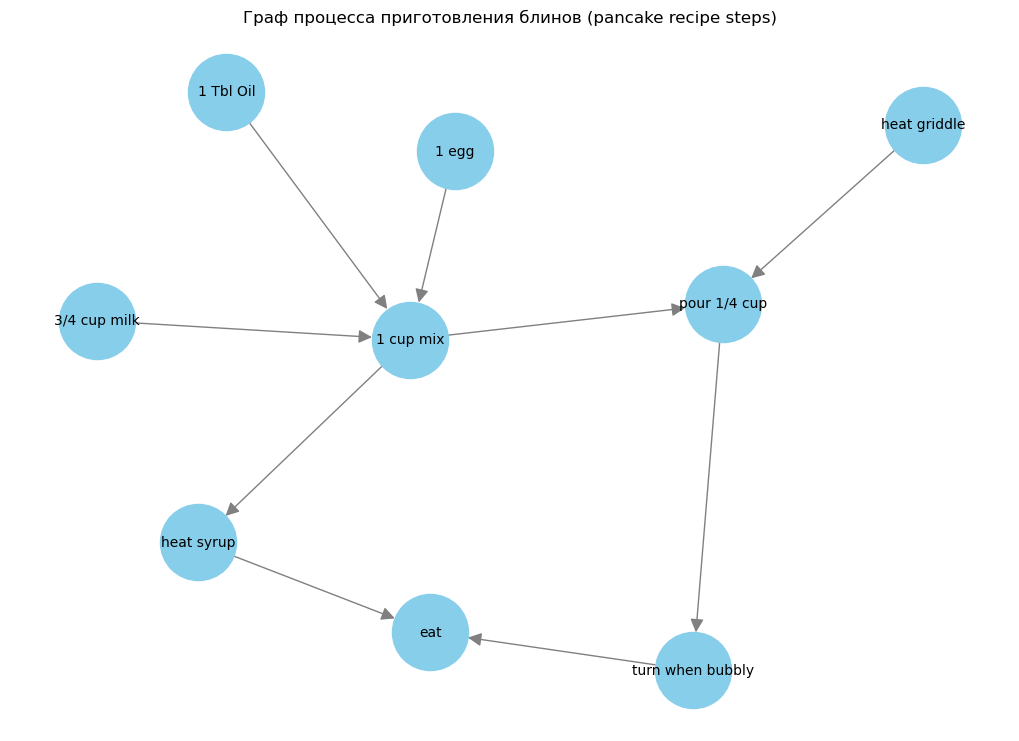

In [12]:
def topological_sort(graph):
    visited = set()
    result = []

    def dfs(vertex):
        visited.add(vertex.getId())
        for neighbor in vertex.getConnections():
            if neighbor.getId() not in visited:
                dfs(neighbor)
        result.append(vertex.getId())  # добавляем вершину после обработки соседей

    for vertex in graph:
        if vertex.getId() not in visited:
            dfs(vertex)
    return result[::-1]  # возвращаем порядок от начала к концу

# шаги
steps = [
    "1 Tbl Oil",
    "1 egg",
    "3/4 cup milk",
    "1 cup mix",
    "heat griddle",
    "pour 1/4 cup",
    "turn when bubbly",
    "eat",
    "heat syrup"
]

# создаём граф
g = Graph()
for step in steps:
    g.addVertex(step)

# рёбра по схеме
g.addEdge("1 Tbl Oil", "1 cup mix")
g.addEdge("1 egg", "1 cup mix")
g.addEdge("3/4 cup milk", "1 cup mix")
g.addEdge("heat griddle", "pour 1/4 cup")
g.addEdge("1 cup mix", "pour 1/4 cup")
g.addEdge("pour 1/4 cup", "turn when bubbly")
g.addEdge("turn when bubbly", "eat")
g.addEdge("1 cup mix", "heat syrup")
g.addEdge("heat syrup", "eat")

order = topological_sort(g)
print("Топологически отсортированные шаги:")
for idx, step in enumerate(order, 1):
    print(f"{idx}. {step}")

G_nx = graph_to_networkx(g)

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G_nx, seed=42)
nx.draw(G_nx, pos, with_labels=True, node_color='skyblue', node_size=3000, font_size=10, arrowsize=20, edge_color='gray')
plt.title("Граф процесса приготовления блинов")
plt.show()

### №4
У вас имеется список городов и набор автобусных маршрутов между ними. Маршруты
однонаправленные, т.е. маршрут вида «город А – город Б» означает, что можно поехать из
города А в город Б, а обратного проезда нет.
Пользователь вводит два города. Ваша программа должна определить минимальный по
количеству километров возможный путь от первого до второго города, или сообщение, что
пути между городами нет. Нужно вывести как количество километров, так и получившейся
путь.
Для решения задачи используйте алгоритм Дейкстры и класс Graph из лекционных
материалов. Список городов и маршрутов возьмите согласно вашему варианту. Расстояние
между городами найдите в интернете самостоятельно.
Также необходимо нарисовать граф вашего варианта (например, здесь
https://graphonline.ru/) и приложить его в ваш отчет.

Вариант 5.

Города:

Киселевск, Прокопьевск, Осинники, Таштагол, Междуреченск, Белово, Красноярск.

Маршруты:

Киселевск – Таштагол

Киселевск – Прокопьевск

Прокопьевск – Междуреченск

Прокопьевск – Белово

Осинники – Красноярск

Таштагол – Осинники

Таштагол – Красноярск

Таштагол – Междуреченск

Междуреченск – Красноярск

Белово – Междуреченск

Белово – Красноярск

Минимальный путь от Киселевск до Красноярск:
Киселевск → Прокопьевск → Белово → Красноярск
Общее расстояние: 736 км


C:\Users\danil\AppData\Local\Temp\ipykernel_8604\597665299.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


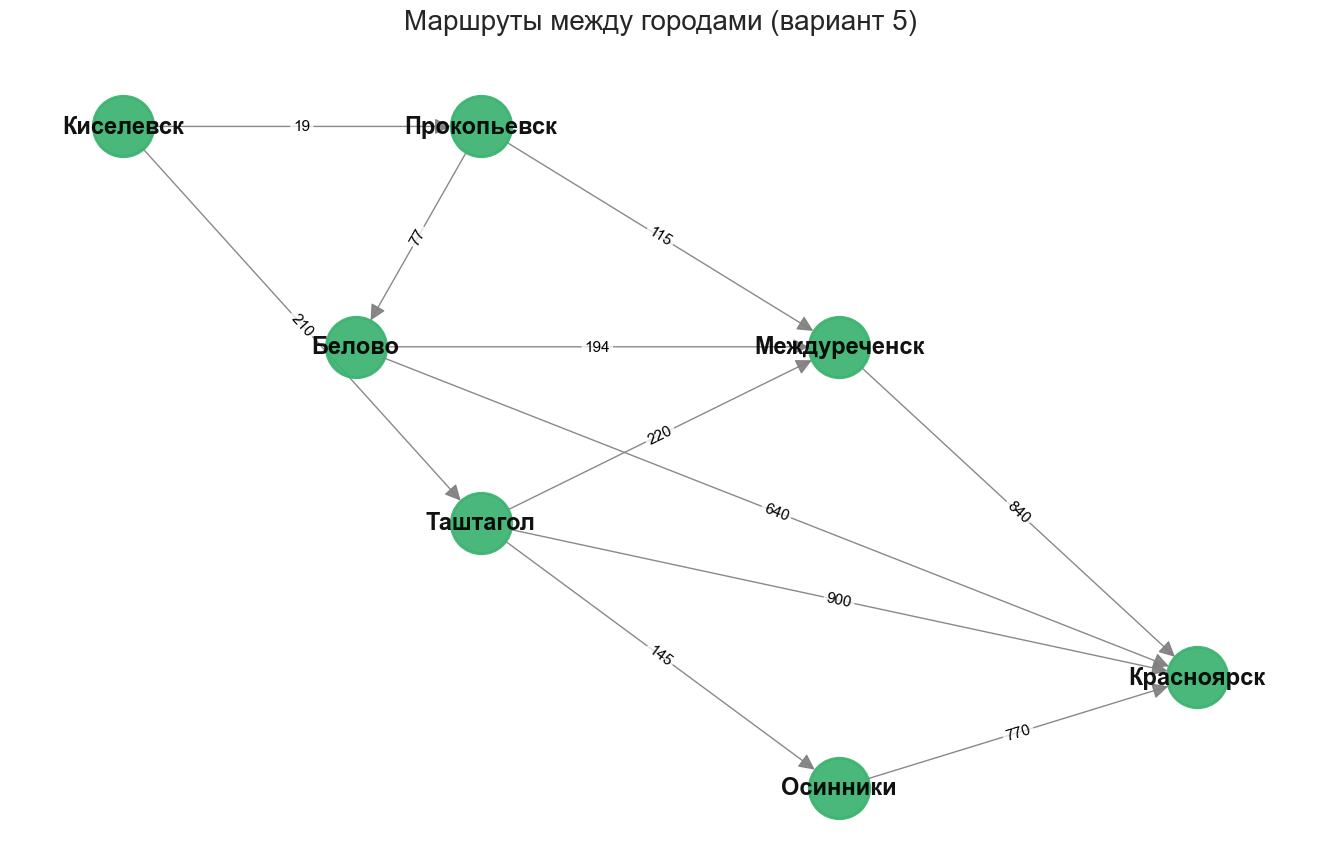

In [19]:
# Шаг 1: определяем города и маршруты
cities = [
    "Киселевск", "Прокопьевск", "Осинники",
    "Таштагол", "Междуреченск", "Белово", "Красноярск"
]

edges = [
    ("Киселевск", "Таштагол", 210),
    ("Киселевск", "Прокопьевск", 19),
    ("Прокопьевск", "Междуреченск", 115),
    ("Прокопьевск", "Белово", 77),
    ("Осинники", "Красноярск", 770),
    ("Таштагол", "Осинники", 145),
    ("Таштагол", "Красноярск", 900),
    ("Таштагол", "Междуреченск", 220),
    ("Междуреченск", "Красноярск", 840),
    ("Белово", "Междуреченск", 194),
    ("Белово", "Красноярск", 640)
]

# Шаг 2: создаем граф
g = Graph()
for city in cities:
    g.addVertex(city)
for f, t, w in edges:
    g.addEdge(f, t, w)

# Шаг 3: Реализуем Дейкстру для поиска кратчайшего пути
import heapq

def dijkstra(graph, start, end):
    queue = []
    heapq.heappush(queue, (0, start, [start]))
    visited = {}

    while queue:
        cost, current, path = heapq.heappop(queue)
        if current == end:
            return cost, path
        if current in visited and visited[current] <= cost:
            continue
        visited[current] = cost
        vertex = graph.getVertex(current)
        for neighbor in vertex.getConnections():
            n_name = neighbor.getId()
            edge_cost = vertex.getWeight(neighbor)
            heapq.heappush(queue, (cost + edge_cost, n_name, path + [n_name]))
    return None, []

city1 = input("Введите начальный город: ")
city2 = input("Введите конечный город: ")
cost, path = dijkstra(g, city1, city2)

if path:
    print(f"Минимальный путь от {city1} до {city2}:")
    print(f"{' → '.join(path)}")
    print(f"Общее расстояние: {cost} км")
else:
    print("Пути между городами нет.")

G_nx = graph_to_networkx(g)

# Задаём координаты
pos = {
    "Киселевск":      (0, 3),
    "Прокопьевск":    (2, 3),
    "Таштагол":       (2, 1.2),
    "Белово":         (1.3, 2),
    "Междуреченск":   (4, 2),
    "Осинники":       (4, 0),
    "Красноярск":     (6, 0.5)
}

plt.figure(figsize=(13, 8))
nx.draw(
    G_nx, pos,
    with_labels=True,
    node_color='mediumseagreen',
    node_size=1900,
    font_size=17,
    font_weight='bold',
    edge_color='gray',
    arrowsize=24,
    linewidths=2,
    alpha=0.93
)
edge_labels = nx.get_edge_attributes(G_nx, 'weight')
nx.draw_networkx_edge_labels(
    G_nx, pos, edge_labels=edge_labels,
    font_color="black", font_size=11,
    bbox=dict(alpha=0.75, color='white', boxstyle='round,pad=0.15')
)
plt.title("Маршруты между городами (вариант 5)", fontsize=20, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()